# EIS Plots

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.data_loading import ECData
from redoxed.plots.eis_plot import NyquistPlot, BodePlot

from redoxed import config
config.set_latex_mode(False) # warning, slows plotting if True. Used to achieve consistent serif fonts by rendering latex. 

%matplotlib inline
# %matplotlib qt

## Autoreload (for development purposes)
## if think is slowing down, disable autoreload by restarting kernel without it.
# %load_ext autoreload
# %autoreload 2 

# Get tab10 colors and names (sadly not colorblind friendly)
cmap = plt.get_cmap('tab10')
tab10_names = [
    "blue", "orange", "green", "red", "purple",
    "brown", "pink", "gray", "olive", "cyan"]
tab10_colors = cmap.colors
# Create a name-to-color dictionary
colour_dict = dict(zip(tab10_names, tab10_colors))
colour_dict["black"] = (0, 0, 0) # add black color

## Multi-Cycle EIS
Often, EIS files will contain more than one dataset

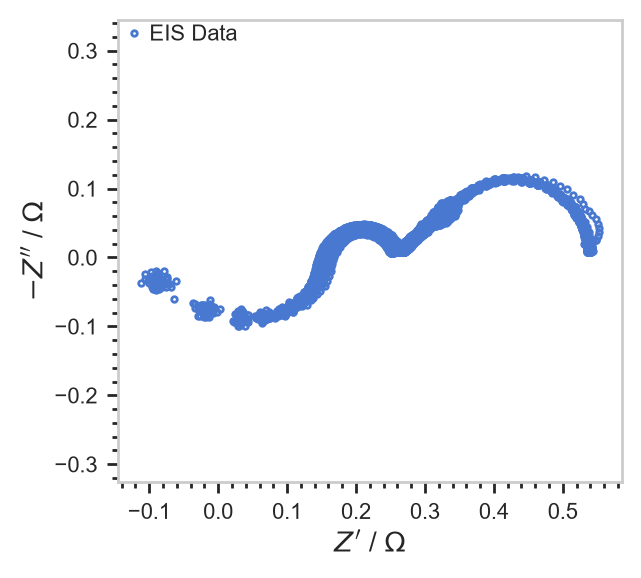

In [ ]:
fpath = r"..\data\cell_EIS_1.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData() # note that loading other formats requires column mapping with df_to_EISData (the default converter used)

data_plot = NyquistPlot(figsize=(3.25, 3), dpi=200) 
data_plot.add_plot(EISData_object, label = "EIS Data", linestyle = "", marker = "o", markersize = 2)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # can always edit afterwards like most settings with something like
## Embellishments
data_plot.add_major_ticks(spacing_x = 0.1, spacing_y = 0.1)
data_plot.add_minor_ticks(number_x=5, number_y=5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
data_plot.ax.legend()

display(data_plot.fig)


We can filter cycles and separate out datasets

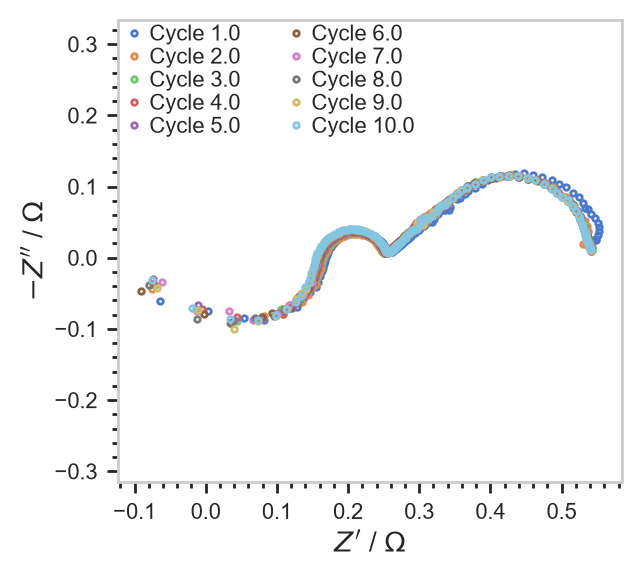

In [6]:
EISData_object_array = []
for cycle in ECData_object.df["cycle number"].unique()[:10]: # limit to first 10 cycles for plotting
    EISData_object = ECData(df = ECData_object.filter_by_col("cycle number", lambda value: value == cycle), label = f"Cycle {cycle}").to_EISData()
    EISData_object_array.append(EISData_object)

data_plot = NyquistPlot(figsize=(3.25, 3), dpi=200) 

for EISData_object in EISData_object_array:
    data_plot.add_plot(EISData_object, label = EISData_object.label, linestyle = "", marker = "o", markersize = 2)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y, but can set x and y lim.
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # Use invisible points if not achieving desired ax limits
## Embellishments
data_plot.add_major_ticks(spacing_x = 0.1, spacing_y = 0.1)
data_plot.add_minor_ticks(number_x=5, number_y=5)
# data_plot.ax.grid(True)
data_plot.ax.legend()
data_plot.ax.legend(ncols = 2, bbox_to_anchor=(0., 1), loc="upper left", fontsize = 8) # manual legend settings


display(data_plot.fig)



## Plotting
Typically, Nyquist or Bode plots are required

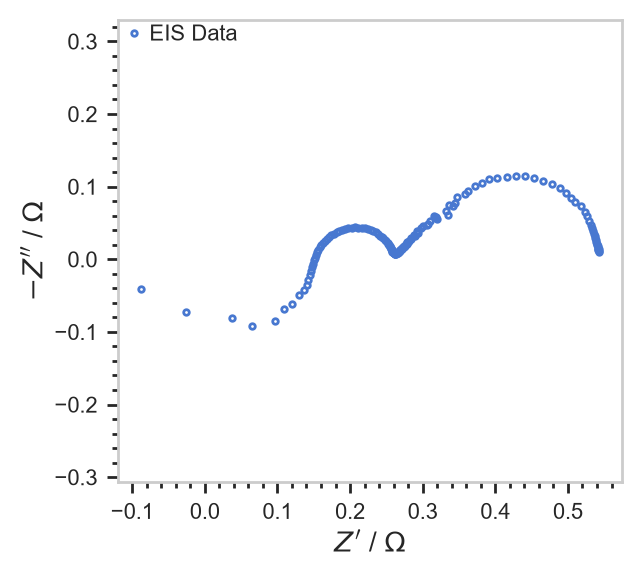

In [15]:
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 20) # select one cycle
EISData_object = ECData_object.to_EISData()

data_plot = NyquistPlot(figsize=(3.25, 3), dpi=200) 
data_plot.add_plot(EISData_object, label = "EIS Data", linestyle = "", marker = "o", markersize = 2)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # can always edit afterwards like most settings with something like
## Embellishments
data_plot.add_major_ticks(spacing_x = 0.1, spacing_y = 0.1)
data_plot.add_minor_ticks(number_x=5, number_y=5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
data_plot.ax.legend()

display(data_plot.fig)

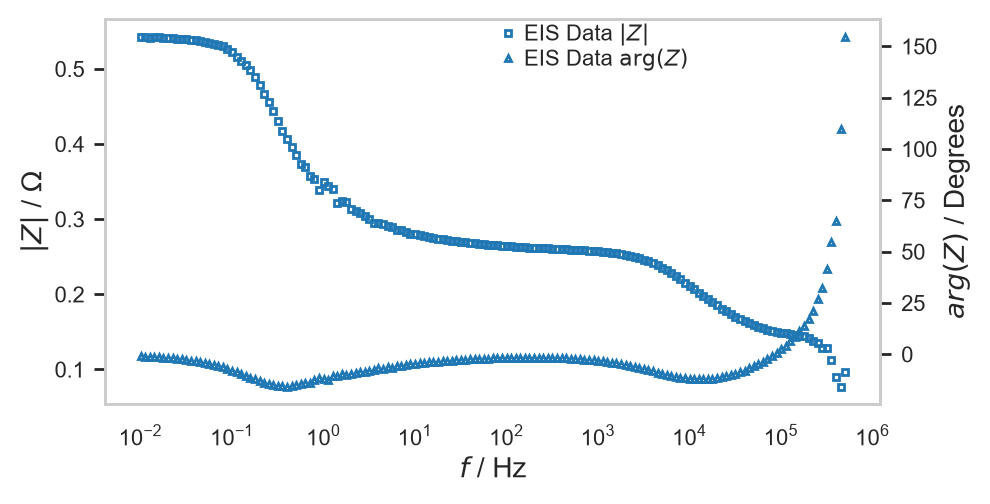

In [16]:
ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 20) # select one cycle
EISData_object = ECData_object.to_EISData()

data_plot = BodePlot(figsize=(5, 2.5), dpi=200) 


data_plot.add_plot(EISData_object, label ="EIS Data", markersize = 2, color = colour_dict["blue"])

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y, but can set x and y lim.
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # Use invisible points if not achieving desired ax limits
## Embellishments
# data_plot.add_major_ticks(spacing_y = 0.1)
# data_plot.add_minor_ticks(number_y = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend()
data_plot.ax.legend(ncols = 1, bbox_to_anchor=(0.5, 1), loc="upper left", fontsize = 8) # manual legend settings


display(data_plot.fig)